In [1]:
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from ugdatalab.plotters.bayesian import plot_posterior, plot_trace


@dataclass(frozen=True)
class MHResult:
    samples: np.ndarray
    log_probs: np.ndarray
    labels: list
    acceptance_rate: float

The archive is unstable and may perform below expectations. If launching multiple, consecutive, heavy queries through Python, please space them out (e.g., using sleep(1)) to avoid overloading the system. Please contact the Gaia helpdesk in case of questions (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk). Workaround solutions for the issues following the December 2025 infrastructure upgrade: https://www.cosmos.esa.int/web/gaia/news#WorkaroundArchive


In [2]:
X = 1.0
SIGMA_X = 0.1


def log_likelihood_1d(mu, x=X, sigma_x=SIGMA_X):
    return -0.5 * ((mu - x) / sigma_x) ** 2 - np.log(sigma_x * np.sqrt(2 * np.pi))


def metropolis_hastings_1d(log_prob, theta0, proposal_std, n_steps, seed=42):
    rng = np.random.default_rng(seed)

    samples = np.empty((n_steps, 1))
    log_probs = np.empty(n_steps)

    theta = float(theta0)
    lp_curr = log_prob(theta)
    n_accepted = 0

    for i in range(n_steps):
        theta_prop = theta + rng.normal(0.0, proposal_std)
        lp_prop = log_prob(theta_prop)
        log_alpha = lp_prop - lp_curr

        if np.log(rng.uniform()) < log_alpha:
            theta = theta_prop
            lp_curr = lp_prop
            n_accepted += 1

        samples[i, 0] = theta
        log_probs[i] = lp_curr

    return MHResult(
        samples=samples,
        log_probs=log_probs,
        labels=[r"$\mu$"],
        acceptance_rate=n_accepted / n_steps,
    )

In [3]:
proposal_grid = [0.05, 0.10, 0.15, 0.18, 0.20, 0.25, 0.30]
proposal_scan = []

for proposal_std in proposal_grid:
    test_chain = metropolis_hastings_1d(
        log_likelihood_1d,
        theta0=0.0,
        proposal_std=proposal_std,
        n_steps=4_000,
        seed=42,
    )
    proposal_scan.append(
        {
            "proposal_std": proposal_std,
            "acceptance_rate": round(test_chain.acceptance_rate, 3),
        }
    )

pd.DataFrame(proposal_scan)

,proposal_std,acceptance_rate
0,0.05,0.839
1,0.10,0.719
2,0.15,0.606
3,0.18,0.547
4,0.20,0.513
5,0.25,0.443
6,0.30,0.384


In [4]:
proposal_std = 0.20
n_steps = 10_000

mh = metropolis_hastings_1d(
    log_likelihood_1d,
    theta0=0.0,
    proposal_std=proposal_std,
    n_steps=n_steps,
)

mu_samples = mh.samples[:, 0]

print(f"Acceptance rate: {mh.acceptance_rate:.3f}")
print(f"Sample mean of μ: {mu_samples.mean():.4f}   (analytic mean: {X:.4f})")
print(f"Sample std of μ:  {mu_samples.std():.4f}   (analytic std:  {SIGMA_X:.4f})")

Acceptance rate: 0.500
Sample mean of μ: 1.0005   (analytic mean: 1.0000)
Sample std of μ:  0.1029   (analytic std:  0.1000)


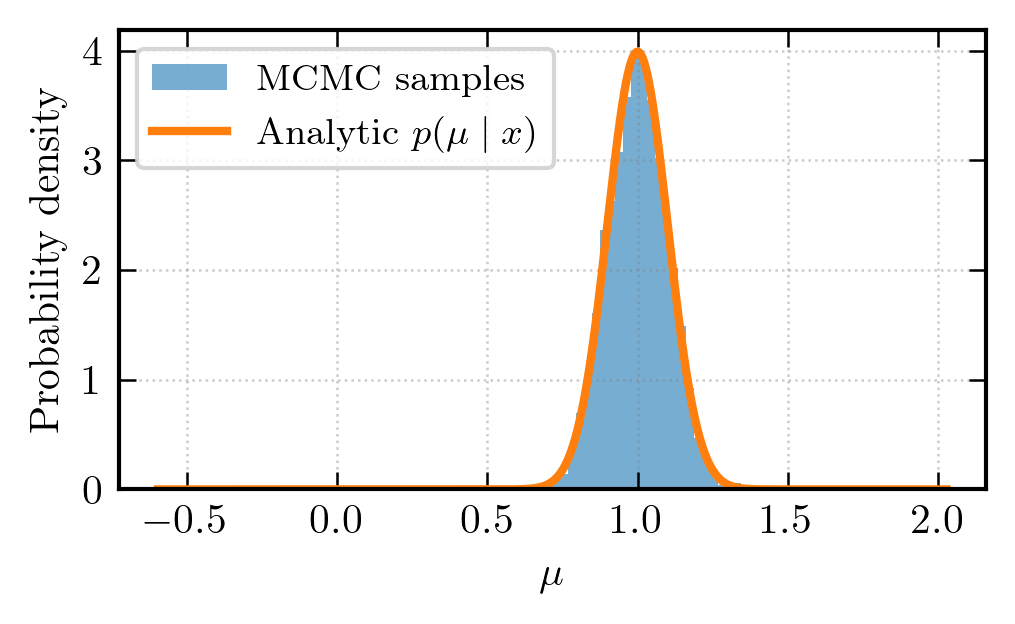

In [5]:
def analytic_pdf(mu, x=X, sigma_x=SIGMA_X):
    return np.exp(-0.5 * ((mu - x) / sigma_x) ** 2) / (sigma_x * np.sqrt(2 * np.pi))


ax = plot_posterior(mh, param_idx=0, pdf_fn=analytic_pdf)
plt.show()

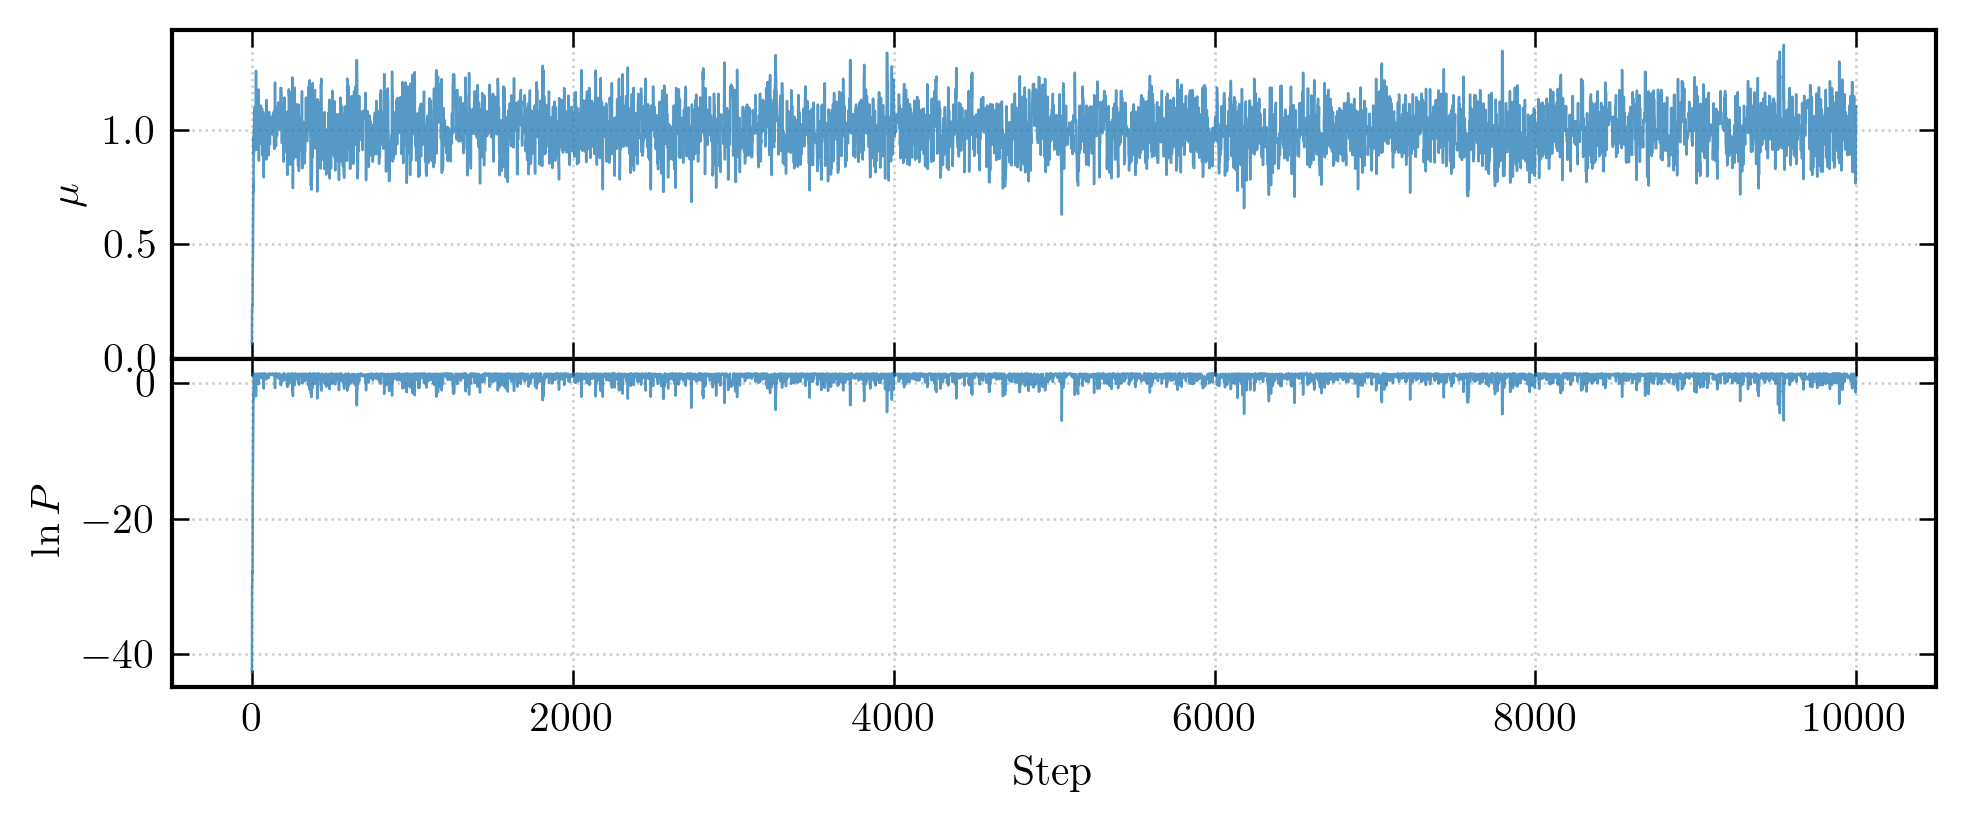

In [6]:
axes = plot_trace(mh)
plt.show()